# ImmoEliza Project: Machine Learning model for price prediction

In this notebook, we will build a model to predict real estate prices, from a dataset of real estate scrapped from Immovlan. 

## Summary of Results: (see more below)
We see that for best performance we should one hot encode provinces. 

**One hot encoded provinces:**
| Regression    | degree | R² train | R² test | MAE (test) | RMSE (test) | Notes : same random state seed per trio |
|---------------|:-------|----------|---------|------------|------------:|-----------------------------------------|
| Lasso         | 2      | 0.7674   | 0.7335  | 91483.31   |   163986.49 | Lasso loves one hot encoding            |
| Random Forest | /      | 0.9663   | 0.7507  | 80874.21   |   158609.43 | Random forest does a bit worse          |
| XGBoost       | /      | 0.9197   | 0.7388  | 84758.37   |   162323.14 | XGboost does a bit worse                |


**Provinces as one Column**
| Regression    | degree | R² train | R² test | MAE (test) | RMSE (test) | Notes : All below use 1 column for provinces |
|---------------|:-------|----------|---------|------------|------------:|----------------------------------------------|
| Lasso         | 2      | 0.7034   | 0.6303  | 101681.54  |   189956.89 | Sweet spot on second degree                  |
| Random Forest | /      | 0.9652   | 0.7658  | 81863.19   |   155009.67 | RF and XGBoost very close on all metrics     |
| XGBoost       | /      | 0.9258   | 0.7286  | 85872.73   |   172640.79 |                                              |


From experiments
With target encoding of (zipcode -> median price per m2 per zipcode)
Broadly speaking, a ten percent gain on the the Rˆ2 for the second degree lasso. This model benefits the most.
A 2-3 points gain on random forest
A ~ 4 points gain on XGBOOST


#### 💡 Refinements :
❗ For some reason, i'm not dropping the duplex and triplex subtypes. they just disappear from the dataset. i don't know why.

🌟 ❗ feature importance : a module in skickit learn. allows to discover which features are helping and which are not. 

- rescrape for bathrooms number
- Infer land area from garden area
- Try split into flats and houses : tried it once need to record better results, but at first approximation, the difference is not huge.
Split in appartments and houses.


## What I did:

### Data Cleaning

- ✅ DROP columns:  
  - locality and region -> redundant with zip code
  - type of glazing (3 possibilities, annoying, captured by energy)
  - type of heating (8 possibilities, annoying to do, somewhat captured by energy, 8k+ nulls + 1700 not specified. almost half empty...) 
  ❓Might want to come back to this

  
- ✅ Categoricals
  - correlated trio (build_year, building_state, energy): keep all of them, let lasso pick the winner. 
  - Building state : keep it as one column. lasso will figure it out. One hot encode possible, but the weight should take care of it, and it's simpler with one column

  
- ✅ Property type / property subtype : We group then one hot encode towards this:
    prop_type_num = 
      flat + studentFlat + loft + flatStudio
      house + masterHouse + mansion
      villa
      mixedBuilding
      duple + triplex
      penthouse
      others = chalet, bungalow, cottage, groundFloor

  
- ✅ Fill in nulls:
  has_terrace : if null -> false
  Before or after the split makes no difference, it's a hard choice.



### Model pre-building:

- ✅ **SPLIT**
  split into X_train, X_test
  > don't forget to drop price from X

- ✅ **Province**
Zipcodes are seperated into 11 provinces. This shows very good results, a bit lower than target encoding of the zipcodes, but more fair.

- ✅ **Target Encoding for the zipcode**
 - 💡 This idea was good, but to make if fair, i should use public data on price/mˆ2/zip. 

    My idea for now is to do this:
    df.groupby(zipcode) get the median price per m2 for that zipcode and write that to a new column for each row. Basically, instead of a zip code i use the median price per m2 for that zipcode.

    > DROP zipcode and price by m2 after this
    ❗Carefull here and below. When doing this, only calculate values for the train set, and map them to the test set. Don't recalculate a new value for the test set, otherwise, i'm leaking info from the test set, into itself. instead, transform the test set with the values from the train set

    ⚠️ This is a bit shaky. I could probably get something equivalent from other public sources : the price m2/zip, but still. 
    When i turn off this feature in the pipeline (just comment out the lines the result is like 20 point lower. So huge effect, less so with xgboost and the random forest but still. )




### Pipeline

- ✅ **Filling Nulls**
  building state (mode)
  number of bedrooms (mode)
  furnished (mode)
  number of facade (mode)

  build year, (median)
  energy (median)
  land area (median)

  ❗Carefull When doing this, only calculate values for the train set, and map them to the test set. Don't recalculate a new value for the test set, otherwise, i'm leaking info from the test set, into itself. instead, transform the test set with the values from the train set

- **Polynomial Expansion**
An option is left to choose the degree of polynomial expansion. Degree 2 showed the best results by far.

- **Standardise**

- **Lasso Regression Model**
Hyperparameter search : loop through possible polynomial degrees. 
> the result is that degree 1 is not very good, degree 2 is the best, 3 is awful when tested. I didn't implement the loop, just changed the degree manually, the results were very clear.


### Test and score the model:

**Results:**

| Regression    | degree | R² train | R² test | MAE test    |   RMSE test | Notes : All below use 1 column for provinces |
|---------------|:-------|----------|---------|-------------|------------:|----------------------------------------------|
| Lasso         | 1      | 0.5161   | 0.5347  | 122083.2209 | 216185.5828 | Not very good                                |
| Lasso         | 1      | 0.5175   | 0.5312  | 115156.8895 | 196481.1784 |                                              |
| Lasso         | 1      | 0.5183   | 0.5234  | 125813.3662 | 227608.4015 |                                              |
| Lasso         | 2      | 0.7034   | 0.6303  | 101681.54   |   189956.89 | Sweet spot on second degree                  |
| Lasso         | 2      | 0.6989   | 0.6624  | 103346.41   |   189685.75 |                                              |
| Lasso         | 2      | 0.7057   | 0.6337  | 104369.97   |   190024.59 |                                              |
| Lasso         | 3      | 0.7902   | 0.1083  | 111135.31   |   312922.71 | Huge variance on 3rd degree: useless.        |
| Lasso         | 3      | 0.78     | 0.5436  | 103956.14   |   216172.57 |                                              |
| Lasso         | 3      | 0.7866   | 0.2483  | 104753.82   |   265645.53 |                                              |
| Random Forest | /      | 0.9652   | 0.7658  | 81863.19    |   155009.67 | RF and XGBoost very close on all metrics     |
| Random Forest | /      | 0.9639   | 0.77    | 80982.98    |   156011.84 |                                              |
| Random Forest | /      | 0.9665   | 0.7275  | 80655.37    |   158095.86 |                                              |
| Random Forest | /      | 0.9653   | 0.7364  | 82972.52    |   161081.83 |                                              |
| XGBoost       | /      | 0.9249   | 0.7542  | 81895.07    |   149897.63 |                                              |
| XGBoost       | /      | 0.9254   | 0.7571  | 82296.91    |    145520.0 |                                              |
| XGBoost       | /      | 0.9247   | 0.7428  | 83915.15    |   157651.24 |                                              |
| XGBoost       | /      | 0.9258   | 0.7286  | 85872.73    |   172640.79 |                                              |
  


**One Hot Encoded Provinces** : 
  
Lasso is greatly improved by one hot encoding, becoming the strongest model, while Random Forest and XGBoost seem to worsen a bit, but not much.
  
(Lasso degree one, slightly improved, degree 3 even worse.)

| Regression    | degree | R² train | R² test | MAE test | RMSE test | Notes : same random state seed per trio |
|---------------|:-------|----------|---------|----------|----------:|-----------------------------------------|
| Lasso         | 2      | 0.7674   | 0.7335  | 91483.31 | 163986.49 | Lasso loves one hot encoding            |
| Random Forest | /      | 0.9663   | 0.7507  | 80874.21 | 158609.43 | Random forest does a bit worse          |
| XGBoost       | /      | 0.9197   | 0.7388  | 84758.37 | 162323.14 | XGboost does a bit worse                |
| Lasso         | 2      | 0.7716   | 0.6944  | 93490.79 | 166118.28 |                                         |
| Random Forest | /      | 0.9653   | 0.7418  | 81505.95 | 152694.38 |                                         |
| XGBoost       | /      | 0.9182   | 0.734   | 83747.48 | 154988.19 |                                         |
| Lasso         | 2      | 0.7719   | 0.7118  | 92908.89 | 165201.11 |                                         |
| Random Forest | /      | 0.967    | 0.7374  | 82243.59 | 157685.26 |                                         |
| XGBoost       | /      | 0.9187   | 0.7126  | 86102.11 | 164985.31 |                                         |





With target encoding of the zipcode -> median price per m2 per zipcode
Broadly speaking, a ten percent gain on the the Rˆ2 for the second degree lasso. This model benefits the most.
A 2-3 points gain on random forest
A ~ 4 points gain on XGBOOST


In [1]:
## Imports
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
plt.style.use('default') # seaborn, ggplot


# For the Model:
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # for the standardisation
from sklearn.linear_model import Lasso  # for the lasso regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# to redo the clean, start from clean_data_for_analysis.csv

# Cleaning done, working from model data
data_file = '../data/clean_data_for_model.csv'
df = pd.read_csv(data_file)
df['furnished'] = df['furnished'].astype('bool') # not sure why that got eaten
df = df.drop(columns=['price_by_m2'])


In [2]:
## Setting provinces : 
def set_province():
    conditions = [
        df['zip_code'].between(1000, 1299), # 1 bxl_cap
        df['zip_code'].between(1300, 1499), # 2 brabant_wallon
        df['zip_code'].between(1300, 1499), # 3 brabant_flamand
        df['zip_code'].between(2000, 2999), # 4 anvers
        df['zip_code'].between(3000, 3499), # 3 brabant_flamand #
        df['zip_code'].between(3500, 3999), # 5 limbourg
        df['zip_code'].between(4000, 4999), # 6 liège
        df['zip_code'].between(5000, 5680), # 7 namur
        df['zip_code'].between(6000, 6599), # 8 hainaut
        df['zip_code'].between(6600, 6999), # 9 luxembourg
        df['zip_code'].between(7000, 7999), # 8 hainaut
        df['zip_code'].between(8000, 8999), # 10 flandre_occidentale
        df['zip_code'].between(9000, 9999), # 11 flandre_orientale
    ] # repeating some like hainaut is easier than conditionals
    
    choices = [1, 2, 3, 4, 3, 5, 6, 7, 8, 9, 8, 10, 11]  # one per conditio
    df['province'] = np.select(conditions, choices, default=0)
   
set_province()
df['province'].value_counts()
df = df.drop(columns=['zip_code'])
    

In [3]:
## One hot Encode of Provinces

df = pd.get_dummies(df, columns=['province'], drop_first=True)
#df = df.drop(columns=['province'])
df.head()

,price,number_of_bedrooms,livable_surface_m2,furnished,has_terrace,has_garden,land_area_m2,number_of_facades,has_swimming_pool,build_year,...,province_2,province_3,province_4,province_5,province_6,province_7,province_8,province_9,province_10,province_11
0,1395000.0,4.0,336.0,True,True,True,5251.0,4.0,False,1955.0,...,False,False,True,False,False,False,False,False,False,False
1,1185000.0,3.0,364.0,False,True,False,NaN,NaN,False,2015.0,...,False,False,True,False,False,False,False,False,False,False
2,572351.0,3.0,138.0,True,False,True,369.0,3.0,False,NaN,...,False,False,True,False,False,False,False,False,False,False
3,1595000.0,5.0,540.0,False,True,True,3896.0,NaN,True,1974.0,...,False,False,True,False,False,False,False,False,False,False
4,549000.0,2.0,149.0,False,True,True,758.0,4.0,False,1986.0,...,False,False,True,False,False,False,False,False,False,False


In [4]:
## Data Cleaned : commented out so i can skip it 

""" 

### Dropping columns
df = df.drop(['locality', 'region', 'type_of_glazing', 'type_of_heating'], axis=1)

### resetting types
df['furnished'] = df['furnished'].astype('bool')
df['has_terrace'] = df['has_terrace'].astype('bool')
df['zip_code'] = df['zip_code'].astype('int')

## Fill in null in has terrace:
df["has_terrace"] = df["has_terrace"].fillna(False)

## Subtype Grouping : I drop property type and keep subtype, after grouping then like so: 
subtype_map = {
    'flat': 'flat',
    'studentFlat': 'flat',
    'loft': 'flat',
    'flatStudio': 'flat',
    'house': 'house',
    'masterHouse': 'house',
    'mansion': 'house',
    'villa': 'villa',
    'mixedBuilding': 'mixed_building',
    'duplex': 'duplex_triplex',
    'triplex': 'duplex_triplex',
    'penthouse': 'penthouse',
    'chalet': 'other',
    'bungalow': 'other',
    'cottage': 'other',
    'groundFloor': 'other',
}

df['prop_group'] = df['property_subtype'].map(subtype_map).fillna('other')
df = pd.get_dummies(df, columns=['prop_group'], drop_first=True)
df = df.drop(columns=['property_type', 'property_subtype'])


# Writing this to file, so it doesn't have to run everytime
df.to_csv("../data/clean_data_for_model.csv", index=False)  # saves without the row index


 """

' \n\n### Dropping columns\ndf = df.drop([\'locality\', \'region\', \'type_of_glazing\', \'type_of_heating\'], axis=1)\n\n### resetting types\ndf[\'furnished\'] = df[\'furnished\'].astype(\'bool\')\ndf[\'has_terrace\'] = df[\'has_terrace\'].astype(\'bool\')\ndf[\'zip_code\'] = df[\'zip_code\'].astype(\'int\')\n\n## Fill in null in has terrace:\ndf["has_terrace"] = df["has_terrace"].fillna(False)\n\n## Subtype Grouping : I drop property type and keep subtype, after grouping then like so: \nsubtype_map = {\n    \'flat\': \'flat\',\n    \'studentFlat\': \'flat\',\n    \'loft\': \'flat\',\n    \'flatStudio\': \'flat\',\n    \'house\': \'house\',\n    \'masterHouse\': \'house\',\n    \'mansion\': \'house\',\n    \'villa\': \'villa\',\n    \'mixedBuilding\': \'mixed_building\',\n    \'duplex\': \'duplex_triplex\',\n    \'triplex\': \'duplex_triplex\',\n    \'penthouse\': \'penthouse\',\n    \'chalet\': \'other\',\n    \'bungalow\': \'other\',\n    \'cottage\': \'other\',\n    \'groundFloor\'

In [5]:
## Importing and Splitting data:

X = df.drop(columns=["price"]) #.to_numpy()  # We need to drop the target column
y = df["price"].to_numpy().reshape(-1 , 1)    # here we do the reshaping in place.
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=None, test_size=0.2)


## Checking the shapes:
print("Shape of X: ", X.shape)  
print("Shape of y: ", y.shape)


Shape of X:  (24441, 31)
Shape of y:  (24441, 1)


In [6]:
#df.columns

In [7]:
## Target encoding the median price by zip code for the pipeline

# baseEstimator is used by the pipeline behind the scene
# TransformerMixing calls fit and transform one after the other in one go.
class ZipCodeTargetEncoder(BaseEstimator, TransformerMixin):  
    """ 
    The fit function learns from the data. 
    The transform function applies what was learned to.
    
    The class doesn't know or care about train vs test — it just processes whatever X it receives
    The pipeline handles calling fit on train and transform on train/test separately
    
    """
    
    def fit(self, X, y=None):
        # compute and store medians from training data
        #self.medians_ = X.groupby('zip_code')['price_by_m2'].median().round()
        #self.nat_median_ = X['price_by_m2'].median()#.round() # in case the zip appears only in the test set
        return self
    
    
    def transform(self, X):
        # map stored medians onto any data
        X = X.copy() # this is good practice
        
        #X["median_PM2_by_zip"] = X["zip_code"].map(self.medians_)
        #X['median_PM2_by_zip'] = X['median_PM2_by_zip'].fillna(self.nat_median_) # if there are nulls, fill them with national average
        #X = X.drop(['zip_code', 'price_by_m2'], axis=1)
        return X

       

In [8]:
df.head()
# the median for build year

#df['build_year'].median()
#X['building_state'].mode()[0]
#X

#print(type(X))
#print(X.columns.tolist() if hasattr(X, 'columns') else "Not a DataFrame!")

,price,number_of_bedrooms,livable_surface_m2,furnished,has_terrace,has_garden,land_area_m2,number_of_facades,has_swimming_pool,build_year,...,province_2,province_3,province_4,province_5,province_6,province_7,province_8,province_9,province_10,province_11
0,1395000.0,4.0,336.0,True,True,True,5251.0,4.0,False,1955.0,...,False,False,True,False,False,False,False,False,False,False
1,1185000.0,3.0,364.0,False,True,False,NaN,NaN,False,2015.0,...,False,False,True,False,False,False,False,False,False,False
2,572351.0,3.0,138.0,True,False,True,369.0,3.0,False,NaN,...,False,False,True,False,False,False,False,False,False,False
3,1595000.0,5.0,540.0,False,True,True,3896.0,NaN,True,1974.0,...,False,False,True,False,False,False,False,False,False,False
4,549000.0,2.0,149.0,False,True,True,758.0,4.0,False,1986.0,...,False,False,True,False,False,False,False,False,False,False


In [9]:
## Filling nulls with median or nulls
class NullFiller(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        ## Getting medians
        self.build_year_median = X['build_year'].median()
        self.energy_median = X['energy_KWh_m2_year'].median()
        self.land_area_median = X['land_area_m2'].median() 
        
        ## Getting modes
        self.build_state_mode = X['building_state'].mode()[0]
        self.num_beds_mode = X['number_of_bedrooms'].mode()[0]
        self.furnished_mode = X['furnished'].mode()[0]
        self.num_facades_mode = X['number_of_facades'].mode()[0]
        self.num_garage_mode = X['number_of_garages'].mode()[0]
    
        return self


    
    def transform(self, X):
        X = X.copy() # this is good practice
        # Writing medians
        X['build_year'] = X['build_year'].fillna(self.build_year_median)
        X['energy_KWh_m2_year'] = X['energy_KWh_m2_year'].fillna(self.energy_median)
        X['land_area_m2'] = X['land_area_m2'].fillna(self.land_area_median)
        
        # Writing modes
        X['building_state'] = X['building_state'].fillna(self.build_state_mode)
        X['number_of_bedrooms'] = X['number_of_bedrooms'].fillna(self.num_beds_mode)
        X['furnished'] = X['furnished'].fillna(self.furnished_mode)
        X['number_of_facades'] = X['number_of_facades'].fillna(self.num_facades_mode)
        X['number_of_garages'] = X['number_of_garages'].fillna(self.num_garage_mode)
        
        ## changing type:
        df['furnished'] = df['furnished'].astype('int')
        

        return X



In [ ]:
## Lasso regression:

degree = 2 # for the polynomial expansion

pipe = Pipeline([('zip_encode', ZipCodeTargetEncoder()),
                 ('fill_nulls', NullFiller()),
                 ('polynomial expansion', PolynomialFeatures(degree=degree)),
                ('scaler', StandardScaler()),
                ('lasso', Lasso(max_iter= 1000, alpha=1.0)),
                  ])

## Calling Lasso regression:
pipe.fit(X_train, y_train)  
predictions = pipe.predict(X_test)
## Printing results
print("R² train:", pipe.score(X_train, y_train))
print("R² test:", pipe.score(X_test, y_test))

y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

r2_train = round(r2_score(y_train, y_pred_train),4)
r2_test = round(r2_score(y_test, y_pred_test), 4)
MAE_train = round(mean_absolute_error(y_train, y_pred_train), 2)
MAE_test = round(mean_absolute_error(y_test, y_pred_test), 2)

RMSE_train = round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2)
RMSE_test = round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2)

print(f"""
| Regression | degree | R² train | R² test | MAE test | RMSE test| 
|------------|:-------|----------|---------|----------|---------:|
| Lasso      |   {degree}    |  {r2_train}  |  {r2_test} | {MAE_test}|  {RMSE_test}| 

""")

## Calling it:
#pipe.fit(X_train, y_train)           # calls fit on each step with X_train
#X_test_transformed = pipe.transform(X_test)  # calls transform on each step with X_test
#X_test_transformed = pipe.transform(X_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.380e+14, tolerance: 1.976e+11
  model = cd_fast.enet_coordinate_descent(


R² train: 0.8578561737757175
R² test: -0.05228507905990476

| Regression | degree | R² train | R² test | MAE test | RMSE test| 
|------------|:-------|----------|---------|----------|---------:|
| Lasso      |   3    |  0.8579  |  -0.0523 | 112812.44|  321501.82| 




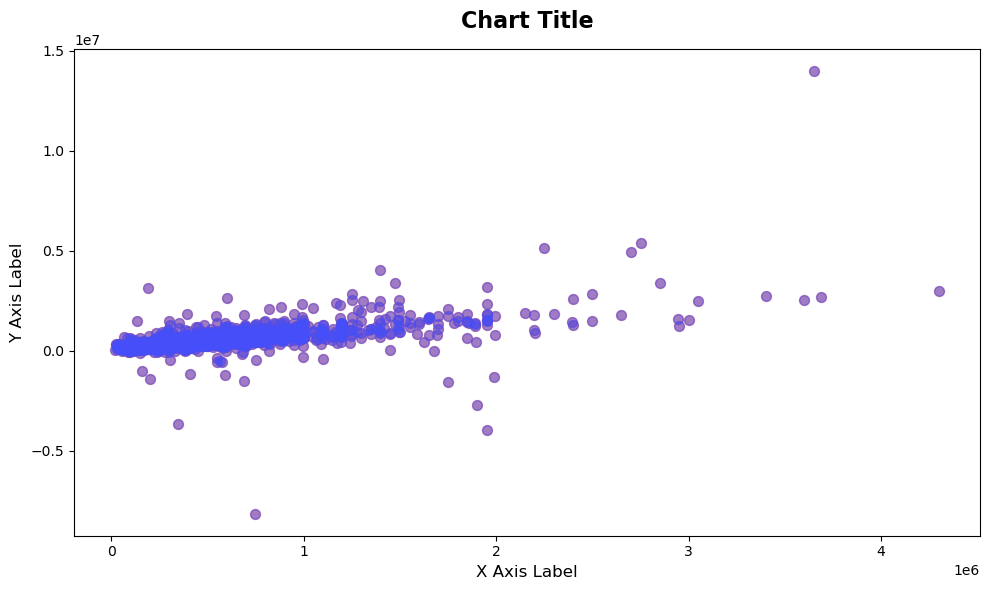

In [11]:
# Visuals

fig, axes = plt.subplots(figsize=(10, 6)) 
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), sharey=True, gridspec_kw={"width_ratios": [2, 1]})  # left is 2x wider than right

# axes.bar(df["x"], df["y"], color="#4CAF50", edgecolor="white", width=0.6, alpha=0.8, label="Series B")
axes.scatter(y_test, predictions, color="#FF5722", s=50, alpha=0.5, label="Series C")
axes.scatter(y_test, predictions, color="#454EF9", s=50, alpha=0.5, label="Series C")


# Title and Labels
axes.set_title("Chart Title", fontsize=16, fontweight="bold", pad=15)
axes.set_xlabel("X Axis Label", fontsize=12)
axes.set_ylabel("Y Axis Label", fontsize=12)



fig.tight_layout()   
#plt.show()

In [12]:
## Debug
## These two are just for testing:
#X_train_transformed = pipe.fit_transform(X_train, y_train)  # fit + transform in one call
#X_train_transformed.isnull().sum()
#X_train_transformed.dtypes
#X_test_temp = pipe[:2].transform(X_test)
#print(X_test_temp["median_PM2_by_zip"].isnull().sum())
#X_train_transformed.isnull().sum()

# debugging
#X_temp = pipe[:2].fit_transform(X_train, y_train)

# Force convert to float (what PolynomialFeatures does internally) and THEN check for NaN

""" arr = X_temp.to_numpy(dtype=float)
print("NaN per column:")
for i, col in enumerate(X_temp.columns):
    n = np.isnan(arr[:, i]).sum()
    if n > 0:
        print(f"  {col}: {n} NaNs")

X_test_temp = pipe[:2].transform(X_test)
print(X_test_temp["median_PM2_by_zip"].isnull().sum())
 """



' arr = X_temp.to_numpy(dtype=float)\nprint("NaN per column:")\nfor i, col in enumerate(X_temp.columns):\n    n = np.isnan(arr[:, i]).sum()\n    if n > 0:\n        print(f"  {col}: {n} NaNs")\n\nX_test_temp = pipe[:2].transform(X_test)\nprint(X_test_temp["median_PM2_by_zip"].isnull().sum())\n '

**Results:**

| Regression    | degree | R² train | R² test | MAE test    |   RMSE test | Notes : All below use 1 column for provinces |
|---------------|:-------|----------|---------|-------------|------------:|----------------------------------------------|
| Lasso         | 1      | 0.5161   | 0.5347  | 122083.2209 | 216185.5828 | Not very good                                |
| Lasso         | 1      | 0.5175   | 0.5312  | 115156.8895 | 196481.1784 |                                              |
| Lasso         | 1      | 0.5183   | 0.5234  | 125813.3662 | 227608.4015 |                                              |
| Lasso         | 2      | 0.7034   | 0.6303  | 101681.54   |   189956.89 | Sweet spot on second degree                  |
| Lasso         | 2      | 0.6989   | 0.6624  | 103346.41   |   189685.75 |                                              |
| Lasso         | 2      | 0.7057   | 0.6337  | 104369.97   |   190024.59 |                                              |
| Lasso         | 3      | 0.7902   | 0.1083  | 111135.31   |   312922.71 | Huge variance on 3rd degree: useless.        |
| Lasso         | 3      | 0.78     | 0.5436  | 103956.14   |   216172.57 |                                              |
| Lasso         | 3      | 0.7866   | 0.2483  | 104753.82   |   265645.53 |                                              |
| Random Forest | /      | 0.9652   | 0.7658  | 81863.19    |   155009.67 | RF and XGBoost very close on all metrics     |
| Random Forest | /      | 0.9639   | 0.77    | 80982.98    |   156011.84 |                                              |
| Random Forest | /      | 0.9665   | 0.7275  | 80655.37    |   158095.86 |                                              |
| Random Forest | /      | 0.9653   | 0.7364  | 82972.52    |   161081.83 |                                              |
| XGBoost       | /      | 0.9249   | 0.7542  | 81895.07    |   149897.63 |                                              |
| XGBoost       | /      | 0.9254   | 0.7571  | 82296.91    |    145520.0 |                                              |
| XGBoost       | /      | 0.9247   | 0.7428  | 83915.15    |   157651.24 |                                              |
| XGBoost       | /      | 0.9258   | 0.7286  | 85872.73    |   172640.79 |                                              |
  


**One Hot Encoded Provinces** : 
  
Lasso is greatly improved by one hot encoding, becoming the strongest model, while Random Forest and XGBoost seem to worsen a bit, but not much.
  
(Lasso degree one, slightly improved, degree 3 even worse.)

| Regression    | degree | R² train | R² test | MAE test | RMSE test | Notes : same random state seed per trio |
|---------------|:-------|----------|---------|----------|----------:|-----------------------------------------|
| Lasso         | 2      | 0.7674   | 0.7335  | 91483.31 | 163986.49 | Lasso loves one hot encoding            |
| Random Forest | /      | 0.9663   | 0.7507  | 80874.21 | 158609.43 | Random forest does a bit worse          |
| XGBoost       | /      | 0.9197   | 0.7388  | 84758.37 | 162323.14 | XGboost does a bit worse                |
| Lasso         | 2      | 0.7716   | 0.6944  | 93490.79 | 166118.28 |                                         |
| Random Forest | /      | 0.9653   | 0.7418  | 81505.95 | 152694.38 |                                         |
| XGBoost       | /      | 0.9182   | 0.734   | 83747.48 | 154988.19 |                                         |
| Lasso         | 2      | 0.7719   | 0.7118  | 92908.89 | 165201.11 |                                         |
| Random Forest | /      | 0.967    | 0.7374  | 82243.59 | 157685.26 |                                         |
| XGBoost       | /      | 0.9187   | 0.7126  | 86102.11 | 164985.31 |                                         |





With target encoding of the zipcode -> median price per m2 per zipcode
Broadly speaking, a ten percent gain on the the Rˆ2 for the second degree lasso. This model benefits the most.
A 2-3 points gain on random forest
A ~ 4 points gain on XGBOOST


In [13]:
## Random Forest:

pipe_rf = Pipeline([
    ('zip_encode', ZipCodeTargetEncoder()),
    ('fill_nulls', NullFiller()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
])

pipe_rf.fit(X_train, y_train)  
#predictions = pipe_rf.predict(X_test)
#print("R² train:", pipe_rf.score(X_train, y_train))
#print("R² test:", pipe_rf.score(X_test, y_test))

y_pred_train = pipe_rf.predict(X_train)
y_pred_test = pipe_rf.predict(X_test)

r2_train = round(r2_score(y_train, y_pred_train),4)
r2_test = round(r2_score(y_test, y_pred_test), 4)
MAE_train = round(mean_absolute_error(y_train, y_pred_train), 2)
MAE_test = round(mean_absolute_error(y_test, y_pred_test), 2)

RMSE_train = round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2)
RMSE_test = round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2)

print(f"""
| Regression | degree | R² train | R² test | MAE test | RMSE test| 
|------------|:-------|----------|---------|----------|---------:|
|Random Forest|   /    |  {r2_train}  |  {r2_test} | {MAE_test}|  {RMSE_test}| 

""")





/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



| Regression | degree | R² train | R² test | MAE test | RMSE test| 
|------------|:-------|----------|---------|----------|---------:|
|Random Forest|   /    |  0.9656  |  0.7499 | 83023.42|  156745.76| 




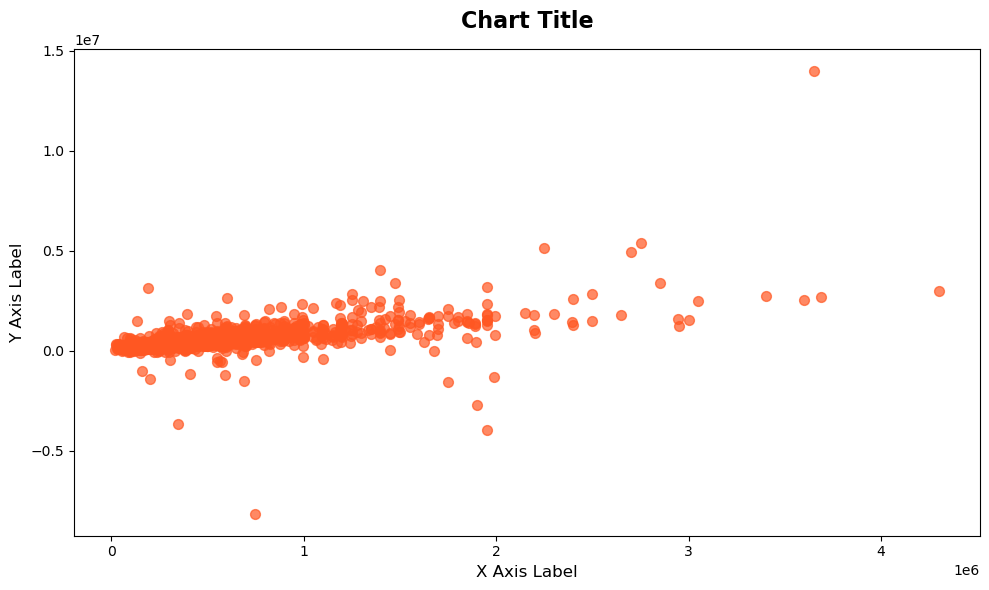

In [14]:
fig, axes = plt.subplots(figsize=(10, 6)) 
# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), sharey=True, gridspec_kw={"width_ratios": [2, 1]})  # left is 2x wider than right

axes.scatter(y_test, predictions, color="#FF5722", s=50, alpha=0.7, label="Series C")
        
# Title and Labels
axes.set_title("Chart Title", fontsize=16, fontweight="bold", pad=15)
axes.set_xlabel("X Axis Label", fontsize=12)
axes.set_ylabel("Y Axis Label", fontsize=12)

fig.tight_layout()   
plt.show()

In [15]:
## XGB regressor
pipe_xgb = Pipeline([
    ('zip_encode', ZipCodeTargetEncoder()),
    ('fill_nulls', NullFiller()),
    ('model', XGBRegressor(n_estimators=100, random_state=42)),
])

pipe_xgb.fit(X_train, y_train.ravel())  # .ravel() on y_train flattens it from shape (n, 1) to (n,)
print("R² train:", pipe_xgb.score(X_train, y_train))
print("R² test:", pipe_xgb.score(X_test, y_test))

## Plotting it:
# predictions
y_pred = pipe_xgb.predict(X_test)

y_pred_train = pipe_xgb.predict(X_train)
y_pred_test = pipe_xgb.predict(X_test)

r2_train = round(r2_score(y_train, y_pred_train),4)
r2_test = round(r2_score(y_test, y_pred_test), 4)
MAE_train = round(mean_absolute_error(y_train, y_pred_train), 2)
MAE_test = round(mean_absolute_error(y_test, y_pred_test), 2)

RMSE_train = round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2)
RMSE_test = round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2)

print(f"""
| Regression | degree | R² train | R² test | MAE test | RMSE test| 
|------------|:-------|----------|---------|----------|---------:|
|XGBoost     |   /    |  {r2_train}  |  {r2_test} | {MAE_test}|  {RMSE_test}| 

""")


R² train: 0.9211760991109736
R² test: 0.7469505099782701

| Regression | degree | R² train | R² test | MAE test | RMSE test| 
|------------|:-------|----------|---------|----------|---------:|
|XGBoost     |   /    |  0.9212  |  0.747 | 84729.12|  157659.25| 




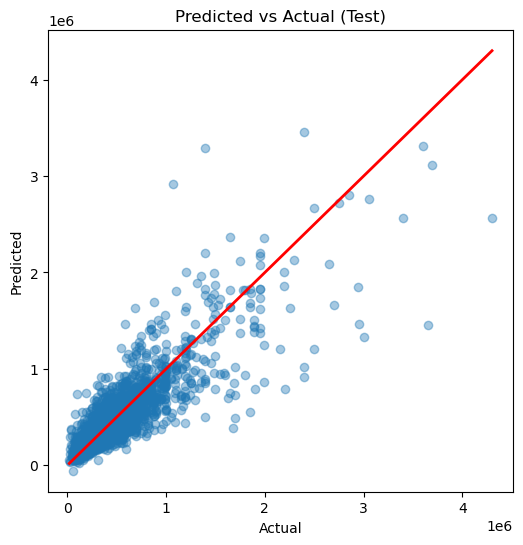

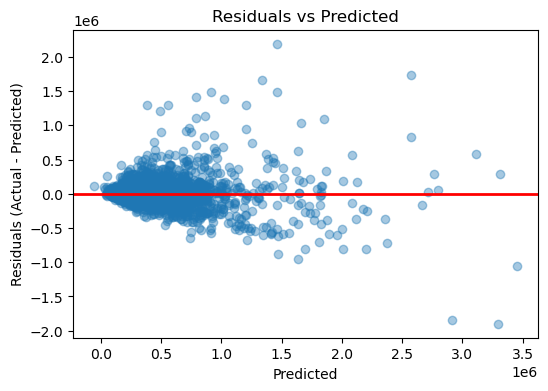

In [16]:
# 1) Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Test)")
plt.show()

# 2) Residuals plot
residuals = y_test.ravel() - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color="red", lw=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.show()


In [17]:
## Trying XgBoost on just flats 

df_f = df.loc[df['prop_group_flat'] == True]

X_f = df_f.drop(columns=["price"]) #.to_numpy()  # We need to drop the target column
y_f = df_f["price"].to_numpy().reshape(-1 , 1)    # here we do the reshaping in place.
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(X_f, y_f, random_state=3, test_size=0.2)

pipe_xgb = Pipeline([
    ('zip_encode', ZipCodeTargetEncoder()),
    ('fill_nulls', NullFiller()),
    ('model', XGBRegressor(n_estimators=100, random_state=42)),
])

pipe_xgb.fit(X_f_train, y_f_train.ravel())  # .ravel() on y_train flattens it from shape (n, 1) to (n,)
print("R² train:", pipe_xgb.score(X_f_train, y_f_train))
print("R² test:", pipe_xgb.score(X_f_test, y_f_test))

## Printing results
#print("R² train:", pipe.score(X_f_train, y_f_train))
#print("R² test:", pipe.score(X_f_test, y_f_test))


R² train: 0.9457359761164759
R² test: 0.6977105955788286
